In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
lambda_rate = 20  
mu_rate = 5      
shift_duration = 8  
np.random.seed(1)

In [7]:
def simulate_call_center(lambda_rate, mu_rate, shift_duration, num_agents=1):
                     
    total_calls = np.random.poisson(lambda_rate * shift_duration)

    inter_arrival_times = np.random.exponential(1 / lambda_rate, total_calls)
    arrival_times = np.cumsum(inter_arrival_times)
    arrival_times = arrival_times[arrival_times < shift_duration] 

    
    service_times = np.random.exponential(1 / mu_rate, len(arrival_times))

   
    agent_available_times = [0.0] * num_agents

    wait_times = []
    system_sizes = []

    for i in range(len(arrival_times)):
        arrival = arrival_times[i]
        service = service_times[i]

        
        next_available_agent = np.argmin(agent_available_times)
        start_service = max(arrival, agent_available_times[next_available_agent])
        wait_time = start_service - arrival

        
        agent_available_times[next_available_agent] = start_service + service

        wait_times.append(wait_time)
        
        active_calls = sum([1 for t in agent_available_times if t > arrival])
        system_sizes.append(active_calls)

    return wait_times, system_sizes


In [9]:
wait_times_1, system_sizes_1 = simulate_call_center(lambda_rate, mu_rate, shift_duration, num_agents=1)
wait_times_1_min = [w * 60 for w in wait_times_1]
avg_wait_1 = np.mean(wait_times_1_min)
avg_system_size_1 = np.mean(system_sizes_1)

print(f"Average Wait Time (1 Agent): {avg_wait_1:.2f} minutes")
print(f"Average System Size (1 Agent): {avg_system_size_1:.2f} people")


Average Wait Time (1 Agent): 776.01 minutes
Average System Size (1 Agent): 1.00 people


In [11]:
lambda_rate = 20
mu_rate = 5
rho = lambda_rate / mu_rate
print(f"Traffic Intensity (ρ): {rho:.2f}")
if rho >= 1:
    print("System is unstable (ρ ≥ 1), theoretical results will be invalid.")
    L = float('inf')
    W = float('inf')
else:

    L = rho / (1 - rho)
    W = L / lambda_rate

    print(f"Theoretical Avg System Size (L): {L:.2f}")
    print(f"Theoretical Avg Time in System (W): {W * 60:.2f} minutes")


Traffic Intensity (ρ): 4.00
System is unstable (ρ ≥ 1), theoretical results will be invalid.


In [13]:
print(f"\nSimulated Avg System Size: {avg_system_size_1:.2f}")
print(f"Simulated Avg Wait Time: {avg_wait_1:.2f} minutes")


Simulated Avg System Size: 1.00
Simulated Avg Wait Time: 776.01 minutes


In [25]:
def evaluate_agents(lambda_rate, mu_rate, shift_duration, max_agents=5, wait_threshold_min=5):
    results = []

    for s in range(1, max_agents + 1):
        wait_times, system_sizes = simulate_call_center(lambda_rate, mu_rate, shift_duration, num_agents=s)
        wait_times_min = [w * 60 for w in wait_times]

        avg_wait = np.mean(wait_times_min)
        p95_wait = np.percentile(wait_times_min, 95)
        avg_system_size = np.mean(system_sizes)

        results.append({
            "Agents": s,
            "Avg Wait (min)": round(avg_wait, 2),
            "95th-pct Wait (min)": round(p95_wait, 2),
            "Avg System Size": round(avg_system_size, 2)
        })

    return results




In [23]:
 results = evaluate_agents(lambda_rate, mu_rate, shift_duration, max_agents=5, wait_threshold_min=5)

In [27]:
import pandas as pd
df_results = pd.DataFrame(results)
print(df_results)
for row in results:
    if row["95th-pct Wait (min)"] <= 5:
        print(f"\n✅ Minimum agents needed to meet 95th-pct wait time ≤ 5 mins: {row['Agents']}")
        break
else:
    print("\n❌ None of the tested agent counts met the 5-minute 95th-pct wait time goal.")



   Agents  Avg Wait (min)  95th-pct Wait (min)  Avg System Size
0       1          682.22              1254.32             1.00
1       2          183.58               342.83             1.99
2       3           66.25               133.02             2.97
3       4           39.13                61.69             3.89
4       5            3.18                12.20             4.48

❌ None of the tested agent counts met the 5-minute 95th-pct wait time goal.


In [29]:
print(df_results)


   Agents  Avg Wait (min)  95th-pct Wait (min)  Avg System Size
0       1          682.22              1254.32             1.00
1       2          183.58               342.83             1.99
2       3           66.25               133.02             2.97
3       4           39.13                61.69             3.89
4       5            3.18                12.20             4.48


In [31]:
for row in results:
    if row["95th-pct Wait (min)"] <= 5:
        optimal_agents = row["Agents"]
        print(f"\n✅ Minimum number of agents needed: {optimal_agents}")
        break
else:
    optimal_agents = None
    print("\n❌ None of the configurations met the 5-minute 95th percentile target.")



❌ None of the configurations met the 5-minute 95th percentile target.


In [33]:
agent_wait_times = {}

for s in range(1, 6):
    wait_times, _ = simulate_call_center(lambda_rate, mu_rate, shift_duration, num_agents=s)
    wait_times_min = [w * 60 for w in wait_times]  
    agent_wait_times[s] = wait_times_min


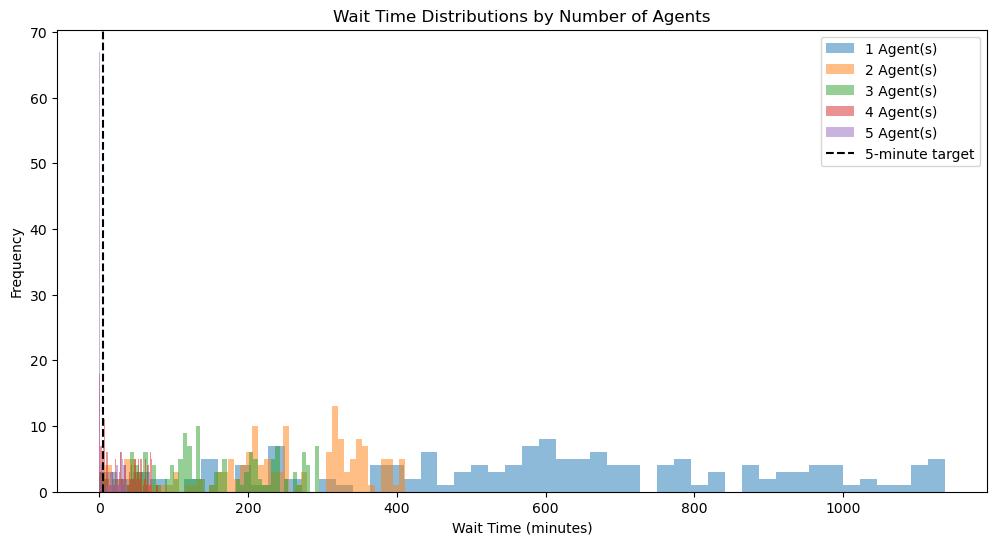

In [39]:
colors = ['red', 'orange', 'green', 'blue', 'purple']
plt.figure(figsize=(12, 6))
for i, (agents, wait_times) in enumerate(agent_wait_times.items()):
    plt.hist(wait_times, bins=50, alpha=0.5, label=f'{agents} Agent(s)')


plt.axvline(x=5, color='black', linestyle='--', label='5-minute target')
plt.xlabel('Wait Time (minutes)')
plt.ylabel('Frequency')
plt.title('Wait Time Distributions by Number of Agents')
plt.legend()
plt.show()


In [41]:
def generate_time_varying_arrivals():
    time_blocks = [(0, 2, 30), (2, 6, 20), (6, 8, 40)]
    arrivals = []

    for start, end, rate in time_blocks:
        duration = end - start
        num_calls = np.random.poisson(rate * duration)
        inter_arrivals = np.random.exponential(1 / rate, num_calls)
        block_arrivals = np.cumsum(inter_arrivals) + start
        block_arrivals = block_arrivals[block_arrivals < end]
        arrivals.extend(block_arrivals)

    arrivals.sort()
    return np.array(arrivals)


In [43]:
def simulate_with_time_varying_lambda(mu_rate, shift_duration, num_agents=3):
    arrival_times = generate_time_varying_arrivals()
    service_times = np.random.exponential(1 / mu_rate, len(arrival_times))
    agent_available_times = [0.0] * num_agents

    wait_times = []

    for i in range(len(arrival_times)):
        arrival = arrival_times[i]
        service = service_times[i]

        next_agent = np.argmin(agent_available_times)
        start_service = max(arrival, agent_available_times[next_agent])
        wait = start_service - arrival
        agent_available_times[next_agent] = start_service + service

        wait_times.append(wait)

    return wait_times


In [45]:
wait_times_var = simulate_with_time_varying_lambda(mu_rate, shift_duration, num_agents=3)
wait_times_var_min = [w * 60 for w in wait_times_var]

avg_wait_var = np.mean(wait_times_var_min)
print(f"📊 Avg Wait Time (3 Agents, Time-Varying λ): {avg_wait_var:.2f} minutes")


📊 Avg Wait Time (3 Agents, Time-Varying λ): 182.86 minutes


In [47]:
def simulate_with_abandonment(lambda_rate, mu_rate, shift_duration, num_agents=4, patience_limit=5):
    total_calls = np.random.poisson(lambda_rate * shift_duration)
    inter_arrivals = np.random.exponential(1 / lambda_rate, total_calls)
    arrival_times = np.cumsum(inter_arrivals)
    arrival_times = arrival_times[arrival_times < shift_duration]

    service_times = np.random.exponential(1 / mu_rate, len(arrival_times))
    agent_available_times = [0.0] * num_agents

    wait_times_served = []
    abandoned_count = 0

    for i in range(len(arrival_times)):
        arrival = arrival_times[i]
        service = service_times[i]

       
        next_agent = np.argmin(agent_available_times)
        start_service = max(arrival, agent_available_times[next_agent])
        wait_time = start_service - arrival

       
        if wait_time > (patience_limit / 60): 
            abandoned_count += 1
        else:
            wait_times_served.append(wait_time)
            agent_available_times[next_agent] = start_service + service

    abandon_rate = 100 * abandoned_count / len(arrival_times)
    avg_wait_served_min = np.mean(wait_times_served) * 60 if wait_times_served else 0

    return abandon_rate, avg_wait_served_min, num_agents


In [49]:
for agents in [3, 4, 5]:
    abandon_rate, avg_wait, a = simulate_with_abandonment(lambda_rate, mu_rate, shift_duration, num_agents=agents)
    print(f"Agents: {a} → Abandon Rate: {abandon_rate:.2f}%, Avg Wait (served): {avg_wait:.2f} min")


Agents: 3 → Abandon Rate: 33.78%, Avg Wait (served): 1.42 min
Agents: 4 → Abandon Rate: 12.67%, Avg Wait (served): 0.55 min
Agents: 5 → Abandon Rate: 14.97%, Avg Wait (served): 0.85 min


In [51]:
def simulate_with_agent_break(lambda_rate, mu_rate, shift_duration, break_start=3.0, break_duration=0.25, num_agents=3):
    total_calls = np.random.poisson(lambda_rate * shift_duration)
    inter_arrivals = np.random.exponential(1 / lambda_rate, total_calls)
    arrival_times = np.cumsum(inter_arrivals)
    arrival_times = arrival_times[arrival_times < shift_duration]

    service_times = np.random.exponential(1 / mu_rate, len(arrival_times))
    
   
    agent_available_times = [0.0] * num_agents

    wait_times = []

    for i in range(len(arrival_times)):
        arrival = arrival_times[i]
        service = service_times[i]

        
        adjusted_availability = []
        for t in agent_available_times:
            if break_start <= t <= break_start + break_duration:
              
                adjusted_availability.append(break_start + break_duration)
            else:
                adjusted_availability.append(t)

        
        next_agent = np.argmin(adjusted_availability)
        start_service = max(arrival, adjusted_availability[next_agent])
        wait = start_service - arrival

        agent_available_times[next_agent] = start_service + service
        wait_times.append(wait)

    avg_wait_min = np.mean(wait_times) * 60
    return avg_wait_min


In [53]:
avg_wait_with_break = simulate_with_agent_break(lambda_rate, mu_rate, shift_duration)
print(f"⏱️ Average Wait Time with 15-min Agent Break: {avg_wait_with_break:.2f} minutes")


⏱️ Average Wait Time with 15-min Agent Break: 106.11 minutes


In [55]:
def calculate_total_cost(lambda_rate, mu_rate, shift_duration, agent_range=range(1, 6), cost_per_hour=20, cost_per_minute=0.5):
    cost_results = []

    for s in agent_range:
        wait_times, _ = simulate_call_center(lambda_rate, mu_rate, shift_duration, num_agents=s)
        wait_times_min = [w * 60 for w in wait_times]
        
       
        num_calls = len(wait_times)
        avg_wait = np.mean(wait_times_min)
        staff_cost = s * cost_per_hour * shift_duration
        wait_cost = avg_wait * num_calls * cost_per_minute
        total_cost = staff_cost + wait_cost

        cost_results.append({
            "Agents": s,
            "Avg Wait (min)": round(avg_wait, 2),
            "Total Calls": num_calls,
            "Staff Cost ($)": round(staff_cost, 2),
            "Wait Cost ($)": round(wait_cost, 2),
            "Total Cost ($)": round(total_cost, 2)
        })

    return pd.DataFrame(cost_results)


In [57]:
df_cost = calculate_total_cost(lambda_rate, mu_rate, shift_duration)
print(df_cost)


   Agents  Avg Wait (min)  Total Calls  Staff Cost ($)  Wait Cost ($)  \
0       1          627.27          144             160       45163.56   
1       2          239.11          148             320       17693.94   
2       3           81.27          152             480        6176.28   
3       4           24.41          144             640        1757.44   
4       5            3.63          170             800         308.72   

   Total Cost ($)  
0        45323.56  
1        18013.94  
2         6656.28  
3         2397.44  
4         1108.72  


In [59]:
min_row = df_cost.loc[df_cost["Total Cost ($)"].idxmin()]
print(f"\n✅ Optimal Agent Count Based on Total Cost: {int(min_row['Agents'])}")
print(f"🔻 Total Cost: ${min_row['Total Cost ($)']:.2f} | Avg Wait: {min_row['Avg Wait (min)']} min")



✅ Optimal Agent Count Based on Total Cost: 5
🔻 Total Cost: $1108.72 | Avg Wait: 3.63 min


In [61]:
def simulate_multiple_days(lambda_rate, mu_rate, shift_duration, num_agents, days=30):
    avg_waits = []
    p95_waits = []

    for _ in range(days):
        wait_times, _ = simulate_call_center(lambda_rate, mu_rate, shift_duration, num_agents=num_agents)
        wait_times_min = [w * 60 for w in wait_times]
        avg_waits.append(np.mean(wait_times_min))
        p95_waits.append(np.percentile(wait_times_min, 95))

    return avg_waits, p95_waits


In [63]:
avg_waits_30, p95_waits_30 = simulate_multiple_days(lambda_rate, mu_rate, shift_duration, num_agents=3)


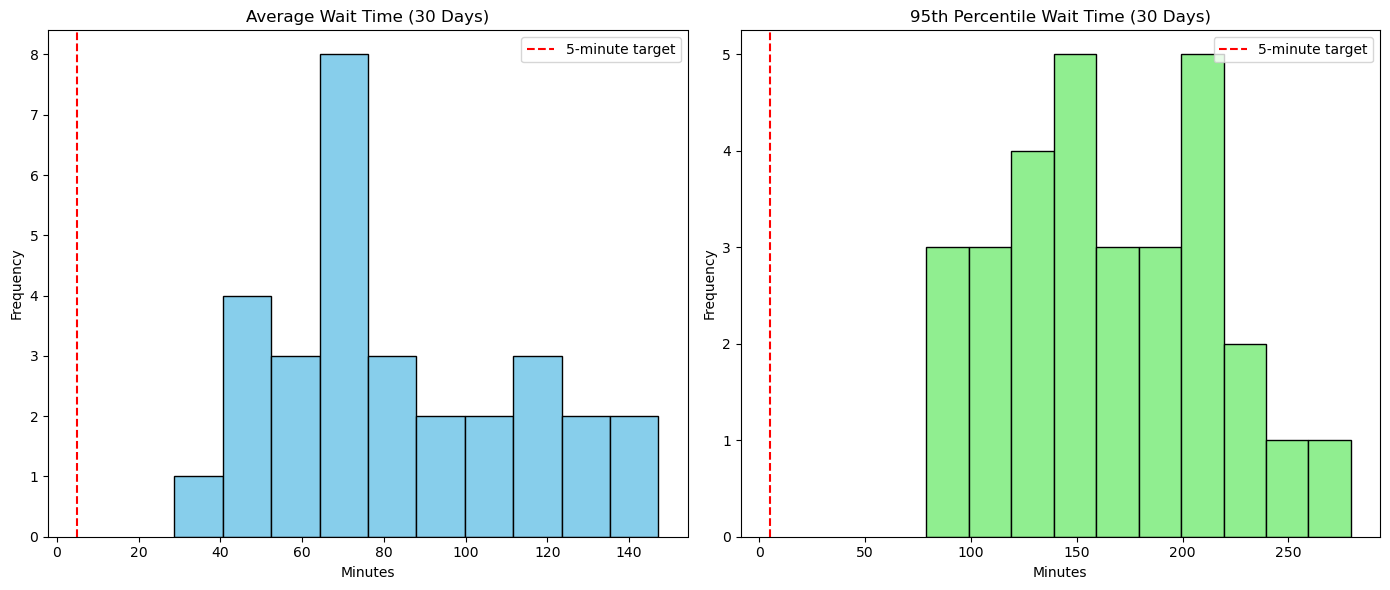

In [65]:
plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
plt.hist(avg_waits_30, bins=10, color='skyblue', edgecolor='black')
plt.axvline(5, color='red', linestyle='--', label='5-minute target')
plt.title('Average Wait Time (30 Days)')
plt.xlabel('Minutes')
plt.ylabel('Frequency')
plt.legend()


plt.subplot(1, 2, 2)
plt.hist(p95_waits_30, bins=10, color='lightgreen', edgecolor='black')
plt.axvline(5, color='red', linestyle='--', label='5-minute target')
plt.title('95th Percentile Wait Time (30 Days)')
plt.xlabel('Minutes')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()
